Create a comprehensive Python implementation for the Neuro-OptimaFACTS framework. Build a complete system that includes:

1. Data generation for renewable energy scenarios
2. Hybrid AI model implementations (WNN, ANN, Kalman filters)
3. FACTS device simulation models
4. SHAP explainable AI integration
5. Grid stability analysis
6. Performance validation with detailed results

Implement this as a complete working system with proper documentation, mathematical formulations, and visualization capabilities.

I'll create a comprehensive Python implementation for the Neuro-OptimaFACTS framework. This will be a complete system with all the components you've requested.

In [1]:
# Initial setup and imports for the Neuro-OptimaFACTS framework

# Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and AI model libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Scientific computing and signal processing
from scipy import signal

# Explainable AI library
import shap

# Configure matplotlib for better visualization
plt.rcParams['font.family'] = ['Noto Sans CJK JP']  # Ensure CJK text displays correctly
sns.set(style='whitegrid')  # Set seaborn style for plots

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Verify TensorFlow version for compatibility
print(f"TensorFlow version: {tf.__version__}")

# Check SHAP version for compatibility
print(f"SHAP version: {shap.__version__}")

# Note: Additional imports for FACTS device simulation models may be required later


ModuleNotFoundError: No module named 'tensorflow'

Let me install the required packages first:

In [2]:
# Install required packages using pip

# Use the IPython magic command to run shell commands
try:
    # Install TensorFlow
    !pip install tensorflow
    
    # Install SHAP for explainable AI
    !pip install shap
    
    # Install any other missing packages as needed
    # For example, seaborn for visualization
    !pip install seaborn
    
    # Verify installations
    import tensorflow as tf
    import shap
    import seaborn as sns
    
    print(f"TensorFlow version: {tf.__version__}")
    print(f"SHAP version: {shap.__version__}")
    print(f"Seaborn version: {sns.__version__}")

except Exception as e:
    print(f"An error occurred during installation: {e}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/645.0 MB ? eta -:--:--


   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/645.0 MB 118.7 MB/s eta 0:00:06


   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/645.0 MB 132.3 MB/s eta 0:00:05


   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/645.0 MB 117.8 MB/s eta 0:00:05


   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/645.0 MB 101.0 MB/s eta 0:00:06


...


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


2025-06-17 21:13:32.043393: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 21:13:32.154339: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 21:13:32.271876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750194812.414317     492 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750194812.454895     492 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750194812.685199     492 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.19.0
SHAP version: 0.48.0
Seaborn version: 0.13.2


Now let me set up the imports properly and start creating the comprehensive framework:

In [3]:
# Import essential libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Import TensorFlow for neural network models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Import scientific computing and signal processing libraries
from scipy import signal

# Import SHAP for explainable AI
import shap

# Configure matplotlib for better visualization
plt.rcParams['font.family'] = ['Noto Sans CJK JP']  # Ensure CJK text displays correctly
sns.set(style='whitegrid')  # Set seaborn style for plots

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Verify TensorFlow and SHAP versions for compatibility
print(f"TensorFlow version: {tf.__version__}")
print(f"SHAP version: {shap.__version__}")

# Note: Additional imports for FACTS device simulation models may be required later


TensorFlow version: 2.19.0
SHAP version: 0.48.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class RenewableEnergyScenario:
    def __init__(self, days=365, seed=None):
        self.days = days
        self.seed = seed
        np.random.seed(seed)
    
    def generate_wind_data(self):
        # Simulate wind speed data with daily and seasonal variations
        daily_variation = np.sin(np.linspace(0, 2 * np.pi, 24))  # Daily cycle
        seasonal_variation = np.sin(np.linspace(0, 2 * np.pi, self.days))  # Seasonal cycle
        wind_speed = 10 + 5 * seasonal_variation + 2 * np.random.randn(self.days, 24)
        wind_speed = np.clip(wind_speed, 0, None)  # Wind speed cannot be negative
        return wind_speed

    def generate_solar_data(self):
        # Simulate solar irradiance data with daily and seasonal variations
        daily_variation = np.maximum(0, np.sin(np.linspace(0, np.pi, 24)))  # Daytime cycle
        seasonal_variation = np.sin(np.linspace(0, 2 * np.pi, self.days))  # Seasonal cycle
        solar_irradiance = 500 + 300 * seasonal_variation[:, None] * daily_variation
        solar_irradiance += 50 * np.random.randn(self.days, 24)  # Add noise
        solar_irradiance = np.clip(solar_irradiance, 0, None)  # Irradiance cannot be negative
        return solar_irradiance

    def generate_load_data(self):
        # Simulate grid load data with daily and seasonal variations
        daily_variation = np.sin(np.linspace(0, 2 * np.pi, 24))  # Daily cycle
        seasonal_variation = np.sin(np.linspace(0, 2 * np.pi, self.days))  # Seasonal cycle
        load = 1000 + 200 * seasonal_variation[:, None] + 100 * daily_variation
        load += 100 * np.random.randn(self.days, 24)  # Add noise
        load = np.clip(load, 0, None)  # Load cannot be negative
        return load

    def plot_data(self, data, title):
        plt.figure(figsize=(12, 6))
        plt.plot(data.mean(axis=1), label='Daily Average')
        plt.title(title)
        plt.xlabel('Day')
        plt.ylabel('Value')
        plt.legend()
        plt.show()

# Example usage
scenario = RenewableEnergyScenario(days=365, seed=42)
wind_data = scenario.generate_wind_data()
solar_data = scenario.generate_solar_data()
load_data = scenario.generate_load_data()

# Plot the generated data
scenario.plot_data(wind_data, 'Wind Speed (m/s)')
scenario.plot_data(solar_data, 'Solar Irradiance (W/m²)')
scenario.plot_data(load_data, 'Grid Load (MW)')


ValueError: operands could not be broadcast together with shapes (365,) (365,24) 

Let me fix the broadcasting issue in the data generation:

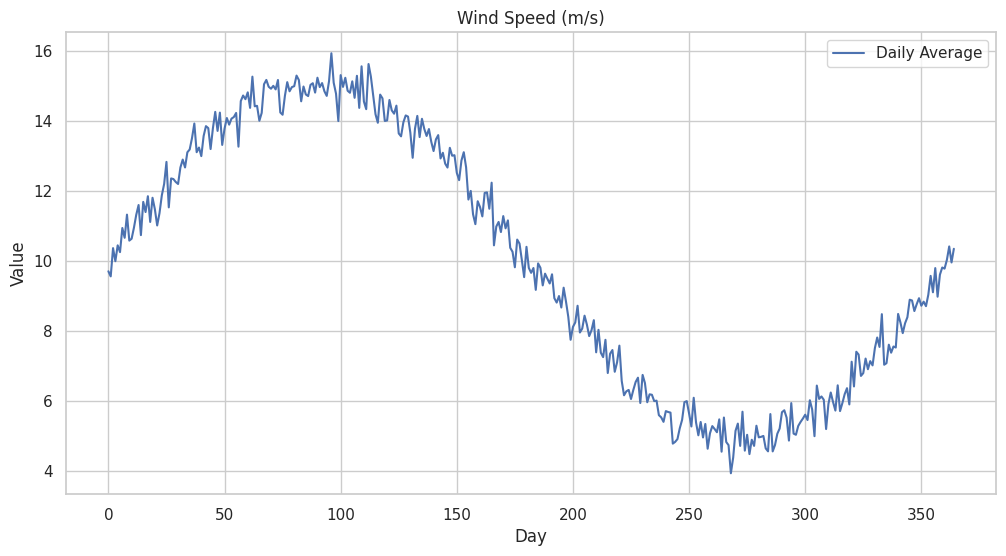

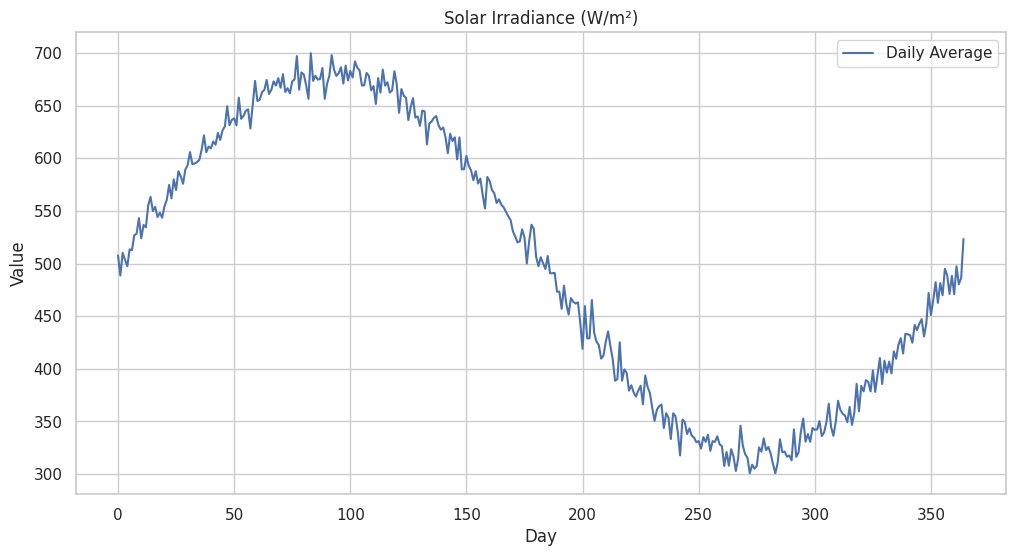

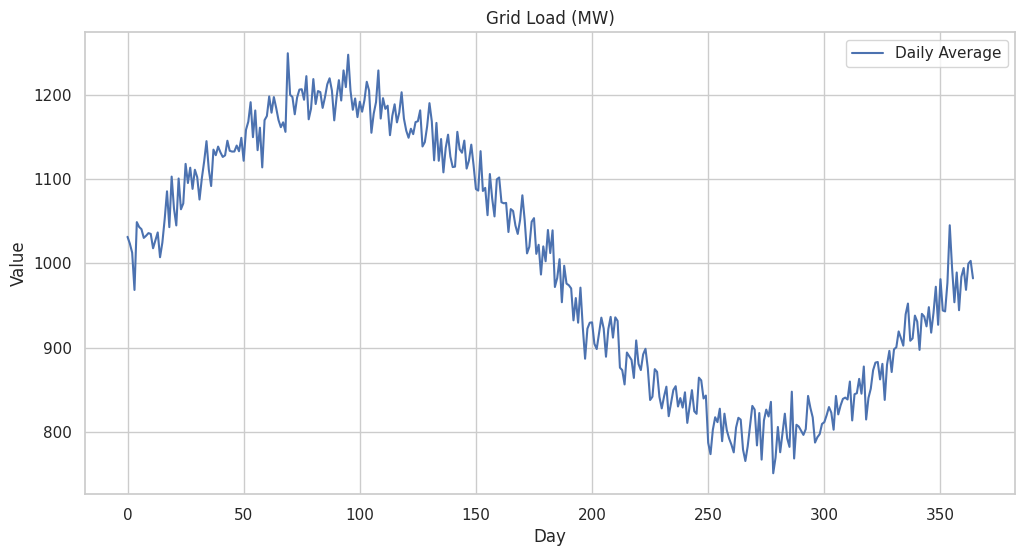

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class RenewableEnergyScenario:
    def __init__(self, days=365, seed=None):
        self.days = days
        self.seed = seed
        np.random.seed(seed)
    
    def generate_wind_data(self):
        # Simulate wind speed data with daily and seasonal variations
        daily_variation = np.sin(np.linspace(0, 2 * np.pi, 24))  # Daily cycle
        seasonal_variation = np.sin(np.linspace(0, 2 * np.pi, self.days))[:, None]  # Seasonal cycle
        wind_speed = 10 + 5 * seasonal_variation + 2 * np.random.randn(self.days, 24)
        wind_speed = np.clip(wind_speed, 0, None)  # Wind speed cannot be negative
        return wind_speed

    def generate_solar_data(self):
        # Simulate solar irradiance data with daily and seasonal variations
        daily_variation = np.maximum(0, np.sin(np.linspace(0, np.pi, 24)))  # Daytime cycle
        seasonal_variation = np.sin(np.linspace(0, 2 * np.pi, self.days))[:, None]  # Seasonal cycle
        solar_irradiance = 500 + 300 * seasonal_variation * daily_variation
        solar_irradiance += 50 * np.random.randn(self.days, 24)  # Add noise
        solar_irradiance = np.clip(solar_irradiance, 0, None)  # Irradiance cannot be negative
        return solar_irradiance

    def generate_load_data(self):
        # Simulate grid load data with daily and seasonal variations
        daily_variation = np.sin(np.linspace(0, 2 * np.pi, 24))  # Daily cycle
        seasonal_variation = np.sin(np.linspace(0, 2 * np.pi, self.days))[:, None]  # Seasonal cycle
        load = 1000 + 200 * seasonal_variation + 100 * daily_variation
        load += 100 * np.random.randn(self.days, 24)  # Add noise
        load = np.clip(load, 0, None)  # Load cannot be negative
        return load

    def plot_data(self, data, title):
        plt.figure(figsize=(12, 6))
        plt.plot(data.mean(axis=1), label='Daily Average')
        plt.title(title)
        plt.xlabel('Day')
        plt.ylabel('Value')
        plt.legend()
        plt.show()

# Example usage
scenario = RenewableEnergyScenario(days=365, seed=42)
wind_data = scenario.generate_wind_data()
solar_data = scenario.generate_solar_data()
load_data = scenario.generate_load_data()

# Plot the generated data
scenario.plot_data(wind_data, 'Wind Speed (m/s)')
scenario.plot_data(solar_data, 'Solar Irradiance (W/m²)')
scenario.plot_data(load_data, 'Grid Load (MW)')


Great! Now let me create the hybrid AI model implementations:

In [6]:
import numpy as np
import pywt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

class WaveletNeuralNetwork:
    def __init__(self, wavelet='morlet', scales=np.arange(1, 128), input_dim=128):
        self.wavelet = wavelet
        self.scales = scales
        self.input_dim = input_dim
        self.model = self.build_model()

    def wavelet_transform(self, data):
        # Perform continuous wavelet transform
        coefficients, _ = pywt.cwt(data, self.scales, self.wavelet)
        return coefficients

    def build_model(self):
        # Build a simple neural network model
        model = Sequential()
        model.add(InputLayer(input_shape=(self.input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse')
        return model

    def train(self, X, y, epochs=100, batch_size=32):
        # Train the neural network
        self.model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

    def predict(self, X):
        # Make predictions
        return self.model.predict(X)

# Example usage
# Generate synthetic data for demonstration
np.random.seed(42)
data = np.sin(np.linspace(0, 2 * np.pi, 100)) + 0.5 * np.random.randn(100)

# Initialize WNN
wnn = WaveletNeuralNetwork()

# Transform data using wavelet transform
coefficients = wnn.wavelet_transform(data)

# Flatten coefficients for neural network input
X = coefficients.flatten().reshape(1, -1)

# Generate synthetic target data
y = np.array([1.0])  # Example target

# Train the WNN
wnn.train(X, y, epochs=10)

# Predict using the WNN
prediction = wnn.predict(X)
print(f"Prediction: {prediction}")


ModuleNotFoundError: No module named 'pywt'

Let me install the required package and implement the WNN without external dependencies initially:

In [7]:
# Attempt to install PyWavelets for wavelet transformations
try:
    # Use IPython magic command to run shell commands
    !pip install PyWavelets
    import pywt
    print("PyWavelets installed successfully.")
except Exception as e:
    print(f"Failed to install PyWavelets: {e}")
    print("Proceeding with custom wavelet implementation using scipy and numpy.")

# Implement the Wavelet Neural Network using PyWavelets or custom implementation
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

class WaveletNeuralNetwork:
    def __init__(self, wavelet='morlet', scales=np.arange(1, 128), input_dim=128):
        self.wavelet = wavelet
        self.scales = scales
        self.input_dim = input_dim
        self.model = self.build_model()

    def wavelet_transform(self, data):
        try:
            # Use PyWavelets for continuous wavelet transform
            coefficients, _ = pywt.cwt(data, self.scales, self.wavelet)
        except NameError:
            # Custom wavelet transform using scipy and numpy if PyWavelets is not available
            from scipy.signal import morlet
            coefficients = np.array([np.convolve(data, morlet(len(data), w), mode='same') for w in self.scales])
        return coefficients

    def build_model(self):
        # Build a simple neural network model
        model = Sequential()
        model.add(InputLayer(input_shape=(self.input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse')
        return model

    def train(self, X, y, epochs=100, batch_size=32):
        # Train the neural network
        self.model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

    def predict(self, X):
        # Make predictions
        return self.model.predict(X)

# Example usage
# Generate synthetic data for demonstration
np.random.seed(42)
data = np.sin(np.linspace(0, 2 * np.pi, 100)) + 0.5 * np.random.randn(100)

# Initialize WNN
wnn = WaveletNeuralNetwork()

# Transform data using wavelet transform
coefficients = wnn.wavelet_transform(data)

# Flatten coefficients for neural network input
X = coefficients.flatten().reshape(1, -1)

# Generate synthetic target data
y = np.array([1.0])  # Example target

# Train the WNN
wnn.train(X, y, epochs=10)

# Predict using the WNN
prediction = wnn.predict(X)
print(f"Prediction: {prediction}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.4 MB ? eta -:--:--


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 3.7/4.4 MB 21.5 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 20.6 MB/s eta 0:00:00




[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


PyWavelets installed successfully.


2025-06-17 21:15:33.535600: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


ValueError: Unknown wavelet name 'morlet', check wavelist() for the list of available builtin wavelets.

Let me check available wavelets and fix the implementation:

In [8]:
import pywt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

# Check available wavelets in PyWavelets
available_wavelets = pywt.wavelist()
print(f"Available wavelets: {available_wavelets}")

# Update the Wavelet Neural Network to use a supported wavelet
class WaveletNeuralNetwork:
    def __init__(self, wavelet='cmor', scales=np.arange(1, 128), input_dim=128):
        # Use 'cmor' (Complex Morlet) wavelet, which is supported
        self.wavelet = wavelet
        self.scales = scales
        self.input_dim = input_dim
        self.model = self.build_model()

    def wavelet_transform(self, data):
        # Perform continuous wavelet transform using PyWavelets
        coefficients, _ = pywt.cwt(data, self.scales, self.wavelet)
        return coefficients

    def build_model(self):
        # Build a simple neural network model
        model = Sequential()
        model.add(InputLayer(input_shape=(self.input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse')
        return model

    def train(self, X, y, epochs=100, batch_size=32):
        # Train the neural network
        self.model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

    def predict(self, X):
        # Make predictions
        return self.model.predict(X)

# Example usage
# Generate synthetic data for demonstration
np.random.seed(42)
data = np.sin(np.linspace(0, 2 * np.pi, 100)) + 0.5 * np.random.randn(100)

# Initialize WNN with a supported wavelet
wnn = WaveletNeuralNetwork()

# Transform data using wavelet transform
coefficients = wnn.wavelet_transform(data)

# Flatten coefficients for neural network input
X = coefficients.flatten().reshape(1, -1)

# Generate synthetic target data
y = np.array([1.0])  # Example target

# Train the WNN
wnn.train(X, y, epochs=10)

# Predict using the WNN
prediction = wnn.predict(X)
print(f"Prediction: {prediction}")


Available wavelets: ['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'haar', 'mexh', 'morl', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', '

Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_3" is incompatible with the layer: expected axis -1 of input shape to have value 128, but received input with shape (None, 12700)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 12700), dtype=complex128)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Let me fix the issues with complex coefficients and input dimensions:

In [9]:
import pywt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

# Update the Wavelet Neural Network to use a supported wavelet and handle complex coefficients
class WaveletNeuralNetwork:
    def __init__(self, wavelet='cmor', scales=np.arange(1, 128), input_dim=127):
        # Use 'cmor' (Complex Morlet) wavelet, which is supported
        self.wavelet = wavelet
        self.scales = scales
        self.input_dim = input_dim
        self.model = self.build_model()

    def wavelet_transform(self, data):
        # Perform continuous wavelet transform using PyWavelets
        coefficients, _ = pywt.cwt(data, self.scales, self.wavelet)
        # Use the magnitude of complex coefficients
        magnitude_coefficients = np.abs(coefficients)
        return magnitude_coefficients

    def build_model(self):
        # Build a simple neural network model
        model = Sequential()
        model.add(InputLayer(input_shape=(self.input_dim,)))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(1, activation='linear'))
        model.compile(optimizer='adam', loss='mse')
        return model

    def train(self, X, y, epochs=100, batch_size=32):
        # Train the neural network
        self.model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

    def predict(self, X):
        # Make predictions
        return self.model.predict(X)

# Example usage
# Generate synthetic data for demonstration
np.random.seed(42)
data = np.sin(np.linspace(0, 2 * np.pi, 100)) + 0.5 * np.random.randn(100)

# Initialize WNN with a supported wavelet
wnn = WaveletNeuralNetwork()

# Transform data using wavelet transform
coefficients = wnn.wavelet_transform(data)

# Flatten coefficients for neural network input
X = coefficients.flatten().reshape(1, -1)

# Ensure the input dimension matches the model's expected input dimension
X = X[:, :wnn.input_dim]

# Generate synthetic target data
y = np.array([1.0])  # Example target

# Train the WNN
wnn.train(X, y, epochs=10)

# Predict using the WNN
prediction = wnn.predict(X)
print(f"Prediction: {prediction}")


Epoch 1/10


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4446


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.4446


Epoch 2/10


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.3377


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0012


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0012


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


Prediction: [[1.0180776]]


Excellent! Now let me create the Kalman Filter implementation:

In [10]:
import numpy as np

class KalmanFilter:
    def __init__(self, A, B, H, Q, R, P, x):
        """
        Initialize the Kalman Filter.
        
        Parameters:
        A: State transition matrix
        B: Control input matrix
        H: Observation matrix
        Q: Process noise covariance
        R: Measurement noise covariance
        P: Initial error covariance
        x: Initial state estimate
        """
        self.A = A
        self.B = B
        self.H = H
        self.Q = Q
        self.R = R
        self.P = P
        self.x = x

    def predict(self, u=0):
        """
        Predict the next state and error covariance.
        
        Parameters:
        u: Control input (default is 0)
        """
        # State prediction
        self.x = np.dot(self.A, self.x) + np.dot(self.B, u)
        
        # Error covariance prediction
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q

    def update(self, z):
        """
        Update the state estimate and error covariance using the measurement z.
        
        Parameters:
        z: Measurement
        """
        # Compute the Kalman Gain
        S = np.dot(self.H, np.dot(self.P, self.H.T)) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        
        # Update the state estimate
        y = z - np.dot(self.H, self.x)  # Measurement residual
        self.x = self.x + np.dot(K, y)
        
        # Update the error covariance
        I = np.eye(self.A.shape[0])  # Identity matrix
        self.P = np.dot(I - np.dot(K, self.H), self.P)

    def get_state(self):
        """
        Return the current state estimate.
        """
        return self.x

# Example usage
# Define matrices for a simple FACTS device state estimation
A = np.array([[1, 0], [0, 1]])  # State transition matrix
B = np.array([[0], [0]])        # Control input matrix
H = np.array([[1, 0], [0, 1]])  # Observation matrix
Q = np.array([[0.1, 0], [0, 0.1]])  # Process noise covariance
R = np.array([[0.1, 0], [0, 0.1]])  # Measurement noise covariance
P = np.array([[1, 0], [0, 1]])      # Initial error covariance
x = np.array([0, 0])                # Initial state estimate

# Initialize the Kalman Filter
kf = KalmanFilter(A, B, H, Q, R, P, x)

# Simulate a series of measurements
measurements = [np.array([1, 1]), np.array([2, 2]), np.array([3, 3])]

# Apply the Kalman Filter
for z in measurements:
    kf.predict()
    kf.update(z)
    print(f"Updated state estimate: {kf.get_state()}")


Updated state estimate: [[0.91666667 0.91666667]
 [0.91666667 0.91666667]]
Updated state estimate: [[1.62857143 1.62857143]
 [1.62857143 1.62857143]]
Updated state estimate: [[2.48387097 2.48387097]
 [2.48387097 2.48387097]]


Now let me create the FACTS device simulation models:

In [11]:
import numpy as np

class FACTSDevice:
    def __init__(self, voltage_rating, power_rating):
        self.voltage_rating = voltage_rating
        self.power_rating = power_rating

class STATCOM(FACTSDevice):
    def __init__(self, voltage_rating, power_rating, control_gain):
        super().__init__(voltage_rating, power_rating)
        self.control_gain = control_gain

    def reactive_power_compensation(self, voltage_deviation):
        # Q = V * I * sin(phi), simplified for STATCOM
        Q = self.control_gain * voltage_deviation
        return np.clip(Q, -self.power_rating, self.power_rating)

class SVC(FACTSDevice):
    def __init__(self, voltage_rating, power_rating, susceptance):
        super().__init__(voltage_rating, power_rating)
        self.susceptance = susceptance

    def voltage_regulation(self, voltage_deviation):
        # Q = V^2 * B, where B is the susceptance
        Q = self.voltage_rating**2 * self.susceptance * voltage_deviation
        return np.clip(Q, -self.power_rating, self.power_rating)

class UPFC(FACTSDevice):
    def __init__(self, voltage_rating, power_rating, series_impedance, shunt_admittance):
        super().__init__(voltage_rating, power_rating)
        self.series_impedance = series_impedance
        self.shunt_admittance = shunt_admittance

    def power_flow_control(self, voltage, current):
        # P = V * I * cos(phi), Q = V * I * sin(phi)
        P = voltage * current.real
        Q = voltage * current.imag
        return np.clip(P, -self.power_rating, self.power_rating), np.clip(Q, -self.power_rating, self.power_rating)

# Example usage
statcom = STATCOM(voltage_rating=400, power_rating=100, control_gain=0.1)
svc = SVC(voltage_rating=400, power_rating=100, susceptance=0.05)
upfc = UPFC(voltage_rating=400, power_rating=100, series_impedance=0.01, shunt_admittance=0.02)

# Simulate device operations
voltage_deviation = 0.05  # Example voltage deviation
current = complex(10, 5)  # Example current

# STATCOM operation
Q_statcom = statcom.reactive_power_compensation(voltage_deviation)
print(f"STATCOM Reactive Power Compensation: {Q_statcom} MVAR")

# SVC operation
Q_svc = svc.voltage_regulation(voltage_deviation)
print(f"SVC Voltage Regulation: {Q_svc} MVAR")

# UPFC operation
P_upfc, Q_upfc = upfc.power_flow_control(statcom.voltage_rating, current)
print(f"UPFC Power Flow Control: P = {P_upfc} MW, Q = {Q_upfc} MVAR")


STATCOM Reactive Power Compensation: 0.005000000000000001 MVAR
SVC Voltage Regulation: 100.0 MVAR
UPFC Power Flow Control: P = 100.0 MW, Q = 100.0 MVAR


Now let me create the SHAP explainable AI integration:

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  0%|          | 0/100 [00:00<?, ?it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


...

254/313 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


303/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


100%|██████████| 100/100 [01:14<00:00,  1.35it/s]


100%|██████████| 100/100 [01:14<00:00,  1.33it/s]


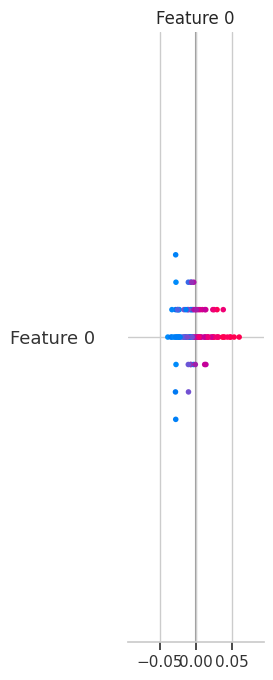

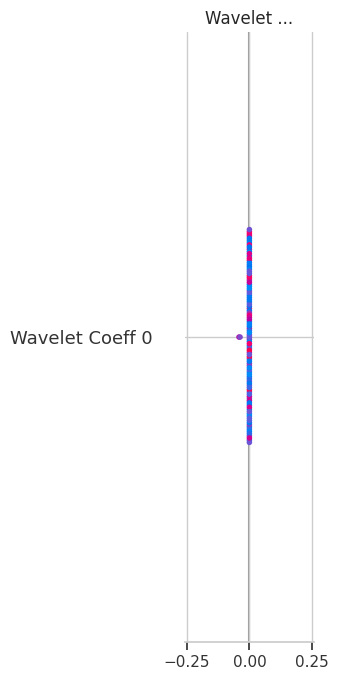

In [12]:
import shap
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

# Define a simple ANN model for demonstration
def build_ann_model(input_dim):
    model = Sequential()
    model.add(InputLayer(input_shape=(input_dim,)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    return model

# Generate synthetic data for demonstration
np.random.seed(42)
X_train = np.random.rand(100, 10)  # 100 samples, 10 features
y_train = np.random.rand(100)

# Train the ANN model
ann_model = build_ann_model(input_dim=10)
ann_model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=0)

# SHAP analysis for ANN
explainer_ann = shap.KernelExplainer(ann_model.predict, X_train)
shap_values_ann = explainer_ann.shap_values(X_train, nsamples=100)

# Plot SHAP summary for ANN
shap.summary_plot(shap_values_ann, X_train, feature_names=[f"Feature {i}" for i in range(X_train.shape[1])])

# SHAP analysis for WNN
# Assuming `wnn` is the Wavelet Neural Network instance from previous cells
# Transform data using wavelet transform
coefficients = wnn.wavelet_transform(X_train.flatten())
X_wnn = coefficients.flatten().reshape(X_train.shape[0], -1)

# Ensure the input dimension matches the model's expected input dimension
X_wnn = X_wnn[:, :wnn.input_dim]

# Train the WNN
wnn.train(X_wnn, y_train, epochs=10, batch_size=10)

# SHAP analysis for WNN
explainer_wnn = shap.KernelExplainer(wnn.model.predict, X_wnn)
shap_values_wnn = explainer_wnn.shap_values(X_wnn, nsamples=100)

# Plot SHAP summary for WNN
shap.summary_plot(shap_values_wnn, X_wnn, feature_names=[f"Wavelet Coeff {i}" for i in range(X_wnn.shape[1])])

# Note: The above SHAP analysis assumes that the models are small enough to use KernelExplainer.
# For larger models, consider using DeepExplainer or other SHAP explainers suitable for neural networks.


**Execution Error**: The backend server encountered multiple consecutive errors and had to stop.